In [3]:
'''
Giulia D'Angelo, giulia.dangelo@fel.cvut.cz

This script creates a single neuron and injects it with current to see the membrane potential dynamics.
From sinabs documentation.
'''

"\nGiulia D'Angelo, giulia.dangelo@fel.cvut.cz\n\nThis script creates a single neuron and injects it with current to see the membrane potential dynamics.\nFrom sinabs documentation.\n"

# Tutorial 3(B): Play with sinabs library  


In the tutorial 3A, we have coded the LIF behaviour from scratch, now we will use the [__sinabs library__](https://www.synsense.ai/products/sinabs/) to simulate [LIF neurons](https://sinabs.readthedocs.io/v3.1.3/auto_examples/layers/plot_lif.html).  
  
In part A you implemented the LIF update rule explicitly:  
```
dVdt = ((VL - V[i-1]) + Rm * I_ext[i]) / tau_m
V[i] = V[i-1] + dVdt * dt
```
Sinabs does something similar internally, but with two differences:  

- __Normalized state space__  
Sinabs LIF works in dimensionless units. There are no Cm, gL, or millivolt values — the membrane potential runs between 0 and 1, and the threshold is fixed at 1 (default), tau_mem is the only free parameter, controlling the leak rate directly.  
  
- __Discrete-time by design__  
In part A, dt was chosen explicitly and we used Euler integration. Sinabs assumes one timestep = one sample, therefore dt is baked in and tau_mem is measured in timesteps, not milliseconds.




### __Task 0: Simulate a single neuron in sinabs__  
This script creates a LIF neuron using the sinabs library and stimulates it with constant current.   
Run the script explore the resulting membrane potential dynamic behaviour.

In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

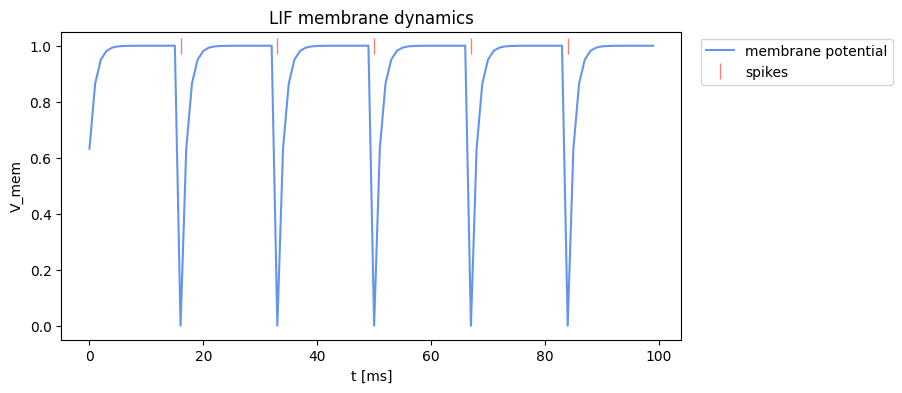

In [61]:
import sinabs.layers as sl

lenstim = 100   # Length of the stimulation ms
tau_mem = 1.0     # Membrane time constant

# Create a neuron using the LIF() class
neuron = sl.LIF(tau_mem=tau_mem)  # Initialize the LIF neuron with a given membrane time constant
neuron.reset_states()

# Input current: shape (batch=1, time=lenstim, neurons=1)
ts = torch.ones(1, lenstim, 1)

vmem = []
spike_train = []
spike_times = []

with torch.no_grad():
    for i in range(lenstim):
        out = neuron(ts[:, i:i+1, :])          # shape (1, 1, 1)
        spike = out.item()                     # 0.0 or >0
        spike_train.append(spike)
        if spike > 0:
            spike_times.append(i)

        vmem.append(neuron.v_mem.item())       # membrane after this step

# Plot membrane potential
plt.figure(figsize=(8, 4))
plt.plot(range(lenstim), vmem, label = "membrane potential", color="cornflowerblue")
plt.plot(spike_times, np.ones(len(spike_times)), "|", markersize=12, label="spikes", color="salmon")
plt.title("LIF membrane dynamics")
plt.xlabel("t [ms]")
plt.ylabel("V_mem")
plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1))
plt.show()


_Additional exploration question:_  
_What role does the torch.no_grad() context play in the simulation, and why is it used in this script?_

### __Task 1: Effects of tau_mem__   
Use the previously provided script to explore how the spiking changes with change in tau_mem.  
Start with initializing a neuron `neuron = sl.LIF(tau_mem=tau_mem, spike_threshold = 0.99)` and see how lowering the firing threshold changed the firing frequency. Then add three more neurons with tau_mem values = {2.0, 5.0, 10.0} and spike_threshold = 0.99.  
Plot all of the obtained dynamics below each other to compare.  

How many times did each of the four neurons spike within the simulation window? 

In [ ]:
lenstim = 100   # Length of the stimulation ms
tau_mem = 1.0   # Membrane time constant to start with

# Input current: shape (batch=1, time=lenstim, neurons=1)
ts = torch.ones(1, lenstim, 1)

# Create a neuron using the LIF() class
neuron = sl.LIF(tau_mem=tau_mem, spike_threshold = 0.99)  # Initialize the LIF neuron with a given membrane time constant
neuron.reset_states()

# TODO 
# Add three more neurons with tau_mem values = {2.0, 5.0, 20.0} 
# and plot the resulting membrane potentials together to see the effect of tau_mem on the membrane dynamics.


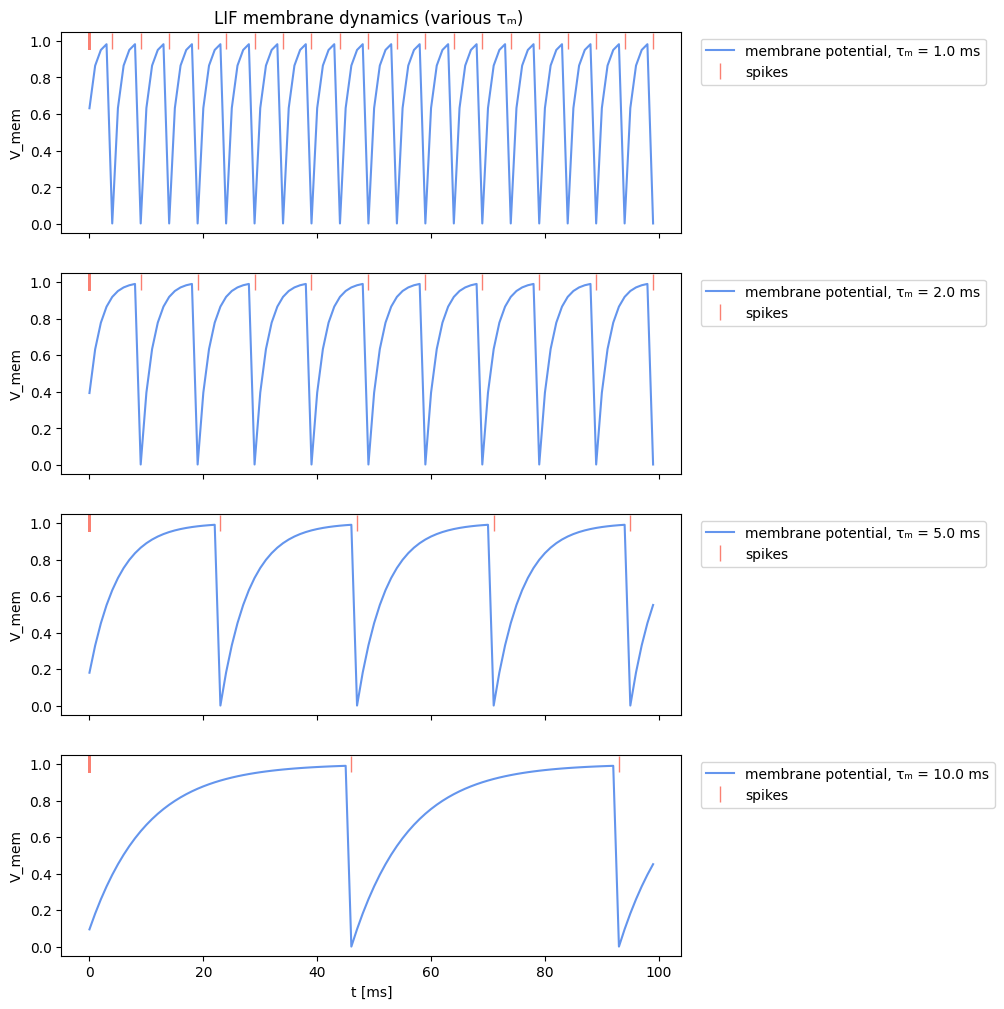

Neurons spiked [np.float64(20.0), np.float64(10.0), np.float64(4.0), np.float64(2.0)] times respectively for tau_mems = [1.0, 2.0, 5.0, 10.0]
Summed up, total number of spikes is  36.0


In [97]:
lenstim = 100   # Length of the stimulation ms
tau_mems = [1.0, 2.0, 5.0, 10.0]     # Membrane time constants

# Input current: shape (batch=1, time=lenstim, neurons=1)
ts = torch.ones(1, lenstim, 1)

# Create a neurons using the LIF() class
neurons = [sl.LIF(tau_mem=tau_mem, spike_threshold = 0.99) for tau_mem in tau_mems ]
for neuron in neurons:
    neuron.reset_states()


vmems = np.zeros((len(neurons), lenstim))
spike_trains = np.zeros((len(neurons), lenstim))
spike_times = np.zeros((len(neurons), lenstim))

with torch.no_grad():
    for n in range(len(neurons)):
        for i in range(lenstim):
            out = neurons[n](ts[:, i:i+1, :])          # shape (1, 1, 1)
            spike = out.item()                     # 0.0 or >0
            spike_trains[n, i] = spike
            if spike > 0:
                spike_times[n, i] = i

            vmems[n, i] = neurons[n].v_mem.item()       # membrane after this step

# Plot membrane potential
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8, 12), sharex=True)
for n in range(4):
    axes[n].plot(range(lenstim), vmems[n, :], label=f"membrane potential, τₘ = {tau_mems[n]} ms", color="cornflowerblue")
    axes[n].plot(spike_times[n], np.ones(len(spike_times[n])), "|", markersize=12, label="spikes", color="salmon")
    axes[n].set_ylabel("V_mem")
    axes[n].legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1))
axes[3].set_xlabel("t [ms]")
plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1.02, 1))
axes[0].set_title(f"LIF membrane dynamics (various τₘ) ")
plt.show()

print(f"Neurons spiked " + f"{[sum(spike_trains[n, :]) for n in range(len(neurons))]}" + f" times respectively for tau_mems = {tau_mems}")
print("Summed up, total number of spikes is ", sum([sum(spike_trains[n, :]) for n in range(len(neurons))]))
